# FICO experiment

In [ ]:
from boundary_trace import GroupScoreDistribution, trace_intersection
from plotting import plot_feasible_regions
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## Setup and data

In [ ]:
fico_url = 'https://raw.githubusercontent.com/fairmlbook/fairmlbook.github.io/master/code/creditscore/data'

fico_totals = pd.read_csv(f'{fico_url}/totals.csv')
fico_cdf = pd.read_csv(f'{fico_url}/transrisk_cdf_by_race_ssa.csv')
fico_perf = pd.read_csv(f'{fico_url}/transrisk_performance_by_race_ssa.csv')

for df in [fico_totals, fico_cdf, fico_perf]:
  df.rename(columns={'Non- Hispanic white': 'White'}, inplace=True)

In [ ]:
races = ['White', 'Black', 'Hispanic', 'Asian']

fico_scores = {}
fico_weights = {}
fico_totals_dict = {}

for race in races:
  fico_scores[race] = 1 - fico_perf[race].to_numpy() / 100
  fico_weights[race] = np.diff(fico_cdf[race].to_numpy(), prepend=0) / 100
  fico_totals_dict[race] = fico_totals[race].iloc[0]

In [ ]:
# Define groupwise score distributions

race01 = ('White', 'Black')

dist0 = GroupScoreDistribution(
    fico_scores[race01[0]],
    fico_weights[race01[0]],
    name=race01[0])

dist1 = GroupScoreDistribution(
    fico_scores[race01[1]],
    fico_weights[race01[1]],
    name=race01[1])

prob_a1 = fico_totals_dict[race01[1]] / (
    fico_totals_dict[race01[0]] + fico_totals_dict[race01[1]])

## Boundary tracing and statistics

In [ ]:
# Unconstrained classifier

acc_unconstrained = (
    (1 - prob_a1) * np.maximum(dist0.s, 1 - dist0.s).dot(dist0.w)
    + prob_a1 * np.maximum(dist1.s, 1 - dist1.s).dot(dist1.w))
print(f'Unconstrained accuracy: {acc_unconstrained:.4f}')

for dist in [dist0, dist1]:
  accept = dist.s >= 0.5
  reject = ~accept

  p_unconstrained = dist.s[accept].dot(dist.w[accept]) / dist.w[accept].sum()
  q_unconstrained = dist.s[reject].dot(dist.w[reject]) / dist.w[reject].sum()

  print(f'Group: {dist.name}\n'
        f'  p = {p_unconstrained:.4f}, q = {q_unconstrained:.4f}')

Unconstrained accuracy: 0.8819
Group: White
  p = 0.9101, q = 0.1980
Group: Black
  p = 0.7854, q = 0.1289


In [ ]:
# Trace intersection boundary

result = trace_intersection(dist0, dist1, prob_a1)
print(result)

TraceResult(
  A=0: White,
  A=1: Black,
  prob_a1 = 0.1207,
  pi_agg  = 0.7077,
  max_acc:  value = 0.8676,
            p = 0.9116, q = 0.2346
  min_dsep: value = 0.0702,
            p = 0.9284, q = 0.2607
)


In [ ]:
# Accuracy at min_dsep

mu_dsep = (result.pi_agg - result.min_dsep.q) / (
    result.min_dsep.p - result.min_dsep.q)

acc_dsep = 1 - result.pi_agg + mu_dsep * (2 * result.min_dsep.p - 1)

print(f'Accuracy at min_dsep: {acc_dsep:.4f}')

Accuracy at min_dsep: 0.8659


In [ ]:
# Are the sufficient optima on the group-specific boundaries?

for dist in result.dists:
  print(f'Group: {dist.name}\n'
        f'  max_acc on boundary =  {dist.is_on_boundary(result.max_acc.p, result.max_acc.q)}\n'
        f'  min_dsep on boundary = {dist.is_on_boundary(result.min_dsep.p, result.min_dsep.q)}')

Group: White
  max_acc on boundary =  False
  min_dsep on boundary = True
Group: Black
  max_acc on boundary =  True
  min_dsep on boundary = True


## Figure

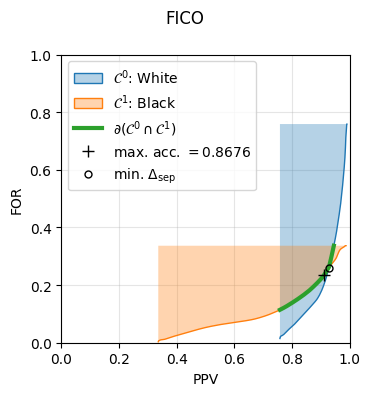

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

plot_feasible_regions(ax, result)

fig.suptitle('FICO')
fig.tight_layout()